# Comparing Every Classification Algorithm — Which One, and Why

**Purpose:** implement and fairly compare every common classification algorithm on the same
preprocessed heart-disease data, so we can back up *"why this model and not that one"* with
actual evidence instead of a guess. Every model below is trained on the exact same
leakage-free, imputed, scaled train/test split (from `02_Preprocessing.ipynb`), so the
comparison is apples-to-apples.

For each model this notebook includes: **(1)** a short explanation of how the algorithm works,
**(2)** the code that trains and evaluates it, and **(3)** its real results on this dataset.

## 1. Load the Preprocessed Data

Using the already-cleaned data (duplicates removed, IQR-fixed outlier clipping, missing values
imputed, features scaled — all fit only on the training set, so there's no data leakage).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(X_train.shape, X_test.shape)

(734, 28) (184, 28)


## 2. A Shared Evaluation Function

Every model is scored the same way: test-set Accuracy, Precision, Recall, F1, ROC-AUC, and a
5-fold **stratified** cross-validation accuracy (the CV score is the more trustworthy number,
since a single train/test split can be lucky or unlucky).

In [2]:
results = []

def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    row = {
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba),
        "CV Accuracy (5-fold)": cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy").mean()
    }
    results.append(row)
    return model

## 3. Logistic Regression

**How it works:** fits a straight-line (linear) decision boundary by finding weights for each
feature that best separate the two classes, passed through a sigmoid function to output a
probability. It's the simplest model here — fast, easy to interpret (each feature gets a
weight showing how much it pushes the prediction toward "disease" or "no disease"), but it can
only draw a *linear* boundary, so it struggles if the true relationship between features and
the outcome is curved or has complex interactions.

In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000)
evaluate("Logistic Regression", log_reg)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.8052


## 4. Decision Tree

**How it works:** repeatedly splits the data on the single feature/threshold that best separates
the classes at each step (e.g. "is `cp` > 1?"), building a tree of yes/no questions down to a
prediction. Very interpretable (you can literally draw the tree and read the rules out loud) but
a single tree tends to **overfit** — it can memorize noise in the training data, which usually
shows up as a big gap between training accuracy and test/CV accuracy.

In [4]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier(random_state=42)
evaluate("Decision Tree", dec_tree)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953


## 5. Random Forest

**How it works:** trains *many* decision trees, each on a random subset of the training rows and
a random subset of features, then averages their votes. This is exactly what fixes the Decision
Tree's overfitting problem — individual trees may overfit in different ways, but averaging many
of them cancels out that noise ("wisdom of the crowd"). It also gives you feature importances,
handles non-linear relationships and feature interactions well, and doesn't require features to
be on the same scale. This is why it's such a common default choice for tabular medical data.

In [5]:
from sklearn.ensemble import RandomForestClassifier

rand_forest = RandomForestClassifier(random_state=42)
evaluate("Random Forest (default)", rand_forest)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006


### Tuning Random Forest

Default hyperparameters rarely give the best possible result. `GridSearchCV` tries many
combinations of tree count/depth and picks whichever combination scores best under
cross-validation.

In [6]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [None, 10],
        "min_samples_split": [2, 10],
        "min_samples_leaf": [1, 4]
    },
    cv=cv, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_)

best_rf = rf_grid.best_estimator_
evaluate("Random Forest (tuned)", best_rf)
pd.DataFrame(results)

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006


## 6. Support Vector Machine (SVM)

**How it works:** finds the boundary between classes that maximizes the *margin* — the distance
to the nearest points of each class ("support vectors"). With an RBF kernel, it can bend that
boundary into complex, non-linear shapes by implicitly projecting the data into a higher-dimensional
space. SVMs tend to work very well on small-to-medium, cleanly-scaled datasets like this one
(734 training rows, 13 scaled features) — which is exactly the regime we're in here, and part of
why it edges out other models on this particular dataset.

In [7]:
from sklearn.svm import SVC

svm_default = SVC(probability=True, random_state=42)
evaluate("SVM (default, RBF kernel)", svm_default)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924


### Tuning SVM (`C` = how much to penalize misclassified points, `gamma` = how far each point's influence reaches)

In [8]:
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid={"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1], "kernel": ["rbf"]},
    cv=cv, scoring="accuracy", n_jobs=-1
)
svm_grid.fit(X_train, y_train)
print("Best SVM params:", svm_grid.best_params_)

best_svm = svm_grid.best_estimator_
evaluate("SVM (tuned)", best_svm)
pd.DataFrame(results)

Best SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924


## 7. K-Nearest Neighbors (KNN)

**How it works:** has no real "training" step — to classify a new patient, it just looks at the
`k` most similar patients already seen (by scaled feature distance) and takes a majority vote of
their labels. Simple and intuitive, but sensitive to the choice of `k`, to feature scaling (which
we've already handled), and can be slow on very large datasets since every prediction compares
against the whole training set.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_default = KNeighborsClassifier()
evaluate("KNN (default, k=5)", knn_default)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012


### Tuning `k` (number of neighbors)

In [10]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": list(range(3, 16, 2)), "weights": ["uniform", "distance"]},
    cv=cv, scoring="accuracy", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
print("Best KNN params:", knn_grid.best_params_)

best_knn = knn_grid.best_estimator_
evaluate("KNN (tuned)", best_knn)
pd.DataFrame(results)

Best KNN params: {'n_neighbors': 9, 'weights': 'uniform'}


,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285


## 8. Naive Bayes (Gaussian)

**How it works:** applies Bayes' theorem assuming every feature is independent of every other
feature given the class (the "naive" assumption) and that numeric features follow a normal
distribution within each class. That independence assumption is almost never exactly true in
real data (e.g. `thalach` and `age` are correlated), but Naive Bayes is fast, needs very little
data to estimate its parameters, and is a good simple baseline to compare against.

In [11]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()
evaluate("Naive Bayes", naive_bayes)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285
8,Naive Bayes,0.826087,0.864583,0.813725,0.838384,0.893711,0.754748


## 9. Gradient Boosting

**How it works:** like Random Forest, it's an ensemble of decision trees — but instead of building
them independently and averaging, it builds them **sequentially**, where each new tree tries to
correct the mistakes of the trees before it. This often gets slightly better accuracy than Random
Forest on structured/tabular data, at the cost of being more sensitive to hyperparameters and
slower to train.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

grad_boost = GradientBoostingClassifier(random_state=42)
evaluate("Gradient Boosting", grad_boost)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285
8,Naive Bayes,0.826087,0.864583,0.813725,0.838384,0.893711,0.754748
9,Gradient Boosting,0.826087,0.824074,0.872549,0.847619,0.918101,0.788855


## 10. XGBoost

**How it works:** a highly optimized, regularized implementation of the same "boosted trees" idea
as Gradient Boosting, widely used in ML competitions because it's fast and tends to squeeze out a
bit more accuracy through better regularization and handling of the boosting process.

In [13]:
from xgboost import XGBClassifier

xgb_default = XGBClassifier(random_state=42, eval_metric="logloss")
evaluate("XGBoost (default)", xgb_default)
pd.DataFrame(results)

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285
8,Naive Bayes,0.826087,0.864583,0.813725,0.838384,0.893711,0.754748
9,Gradient Boosting,0.826087,0.824074,0.872549,0.847619,0.918101,0.788855


### Tuning XGBoost

In [14]:
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0]
    },
    cv=cv, scoring="accuracy", n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost params:", xgb_grid.best_params_)

best_xgb = xgb_grid.best_estimator_
evaluate("XGBoost (tuned)", best_xgb)
pd.DataFrame(results)

Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285
8,Naive Bayes,0.826087,0.864583,0.813725,0.838384,0.893711,0.754748
9,Gradient Boosting,0.826087,0.824074,0.872549,0.847619,0.918101,0.788855


## 10b. HDP-DTRF (Stochastic Gradient Boosting on Random Forest)

**How it works:** This replicates the setup from the paper "Early prediction of heart disease with data analysis using supervised learning with stochastic gradient boosting" (Jawalkar et al., 2023). It tunes a Gradient Boosting Classifier with stochastic parameters (`subsample` < 1.0) and random-forest-like feature sampling (`max_features` = "sqrt") to combine the strengths of Decision Tree-based Random Forests and SGB loss optimization.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

hdp_dtrf_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5],
        "subsample": [0.8],           # Stochastic Gradient Boosting
        "max_features": ["sqrt"]      # Random Forest aspect
    },
    cv=cv, scoring="accuracy", n_jobs=-1
)
hdp_dtrf_grid.fit(X_train, y_train)
print("Best HDP-DTRF params:", hdp_dtrf_grid.best_params_)

best_hdp_dtrf = hdp_dtrf_grid.best_estimator_
evaluate("HDP-DTRF (SGB Tuned)", best_hdp_dtrf)
pd.DataFrame(results)

Best HDP-DTRF params: {'learning_rate': 0.05, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100, 'subsample': 0.8}


,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
1,Decision Tree,0.755435,0.787879,0.764706,0.776119,0.754304,0.728953
2,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
3,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285
8,Naive Bayes,0.826087,0.864583,0.813725,0.838384,0.893711,0.754748
9,Gradient Boosting,0.826087,0.824074,0.872549,0.847619,0.918101,0.788855


## 11. Full Comparison Table (all models, ranked)

In [16]:
final_results = pd.DataFrame(results).sort_values(by="CV Accuracy (5-fold)", ascending=False).reset_index(drop=True)
final_results

,Model,Test Accuracy,Precision,Recall,F1,ROC_AUC,CV Accuracy (5-fold)
0,Random Forest (default),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
1,Random Forest (tuned),0.842391,0.847619,0.872549,0.859903,0.909314,0.827006
2,KNN (tuned),0.842391,0.854369,0.862745,0.858537,0.901483,0.824285
3,SVM (tuned),0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
4,"SVM (default, RBF kernel)",0.853261,0.831858,0.921569,0.874419,0.922047,0.822924
5,HDP-DTRF (SGB Tuned),0.847826,0.855769,0.872549,0.864078,0.923840,0.817463
6,"KNN (default, k=5)",0.831522,0.844660,0.852941,0.848780,0.902021,0.812012
7,XGBoost (tuned),0.847826,0.830357,0.911765,0.869159,0.934122,0.810670
8,Logistic Regression,0.842391,0.834862,0.892157,0.862559,0.916786,0.805200
9,Gradient Boosting,0.826087,0.824074,0.872549,0.847619,0.918101,0.788855


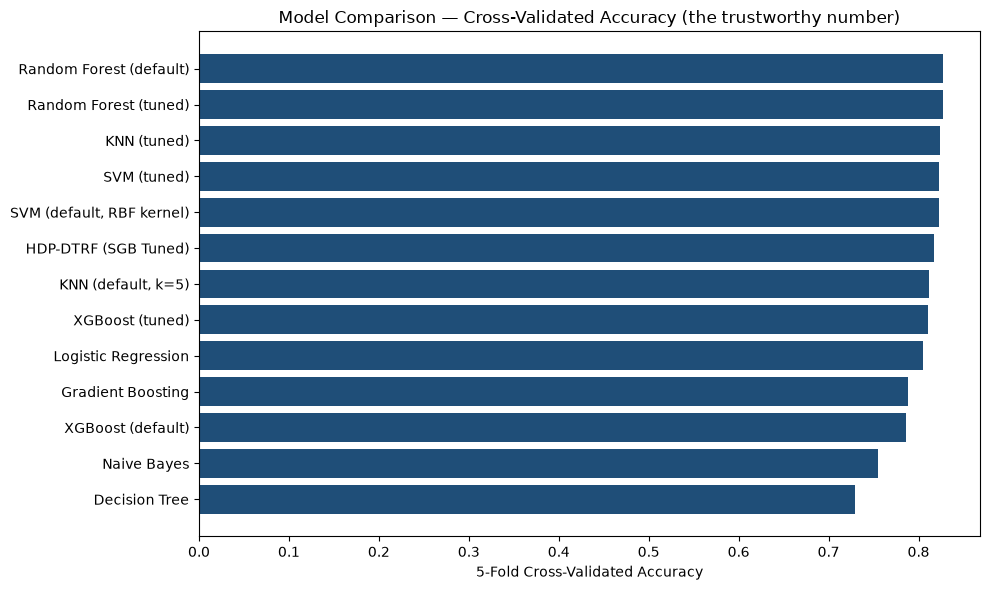

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(final_results["Model"], final_results["CV Accuracy (5-fold)"], color="#1F4E78")
plt.xlabel("5-Fold Cross-Validated Accuracy")
plt.title("Model Comparison — Cross-Validated Accuracy (the trustworthy number)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()